In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\User\Desktop\ab_test_data.csv")
df.head(3)

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


In [6]:
df.describe()

,conversion
count,19998.000000
mean,0.075008
std,0.263410
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [7]:
# Створюємо таблицю для аналізу якості даних
quality_report = pd.DataFrame({
    'тип_даних': df.dtypes,
    'пропуски_NaN': df.isna().sum(),
    'частка_NaN_%': (df.isna().mean() * 100).round(2),
    'нулі_0': (df == 0).sum(),
    'унікальні_значення': df.nunique()
})

print(quality_report)

           тип_даних  пропуски_NaN  частка_NaN_%  нулі_0  унікальні_значення
user_id       object             0           0.0       0               19998
timestamp     object             0           0.0       0               19998
test_group    object             0           0.0       0                   2
conversion     int64             0           0.0   18498                   2


 ми отримали рівно 2 групи (test_group) та  всі user_id унікальні.

In [8]:
# Групуємо дані за тестовою групою та рахуємо метрики
results = df.groupby('test_group')['conversion'].agg(['count', 'sum', 'mean']).reset_index()

# Перейменовуємо стовпці для зручності
results.columns = ['Група', 'К-сть користувачів', 'К-сть конверсій', 'Конверсія (CR)']

# Переводимо CR у відсотки
results['Конверсія (CR)'] = (results['Конверсія (CR)'] * 100).round(2)

print(results)

  Група  К-сть користувачів  К-сть конверсій  Конверсія (CR)
0     a               10013              611             6.1
1     b                9985              889             8.9


In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
start_date = df['timestamp'].min()
end_date = df['timestamp'].max()
duration = (end_date - start_date).days

print(f"Тест почався: {start_date}")
print(f"Тест закінчився: {end_date}")
print(f"Тривалість тесту: {duration} днів")

Тест почався: 2023-07-03 01:42:34.033708
Тест закінчився: 2023-07-25 01:41:19.152664
Тривалість тесту: 21 днів


In [10]:
from scipy import stats

#  Розділяємо дані на дві групи 
group_a = df[df['test_group'] == 'a']['conversion']
group_b = df[df['test_group'] == 'b']['conversion']

#  Виконуємо t-test для незалежних вибірок
t_stat, p_value = stats.ttest_ind(group_a, group_b)

print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

#  Перевіримо гіпотези 
alpha = 0.05
if p_value < alpha:
    print("Висновок: Відхиляємо нульову гіпотезу. Різниця статистично значуща.")
else:
    print("Висновок: Немає підстав відхиляти нульову гіпотезу. Різниця випадкова.")

t-статистика: -7.5300
p-value: 0.0000
Висновок: Відхиляємо нульову гіпотезу. Різниця статистично значуща.


чим більша t_stat, тим далі один від одного розходяться довірчі інтервали на графіку кщо t_stat велика, то p-value стає меншим за 0,05.

In [ ]:
# 1. Розрахунок середніх
mean_a = group_a.mean()
mean_b = group_b.mean()

# 2. Розрахунок Lift (відносного приросту)
lift = (mean_b - mean_a) / mean_a
print(f"Відносний приріст (Lift): {lift:.2%}")

# 3. Розрахунок 95% довірчого інтервалу для різниці конверсій
# Використовуємо стандартну помилку для часток
std_error = np.sqrt((mean_a * (1 - mean_a) / len(group_a)) + (mean_b * (1 - mean_b) / len(group_b)))
margin_of_error = 1.96 * std_error

ci_lower = (mean_b - mean_a) - margin_of_error
ci_upper = (mean_b - mean_a) + margin_of_error

print(f"95% CI для різниці: [{ci_lower:.4f} ... {ci_upper:.4f}]")

scipy.stats.ttest_ind: Ми застосували цей критерій, оскільки порівнюємо середні значення двох незалежних груп (А та В).t-статистика: Це значення показує розмір різниці між групами відносно стандартної помилки. Чим воно більше за модулем, тим менш ймовірно, що результат випадковий.p-value: Це головний показник значущості. Якщо він менший за 0,05, ми впевнені на 95%, що ефект від "знижки 50%" справжній, а не просто везіння.Нульова гіпотеза ($H_0$): Припускає, що новий дизайн екрана ніяк не впливає на загальну конверсію з інстала в платіж.

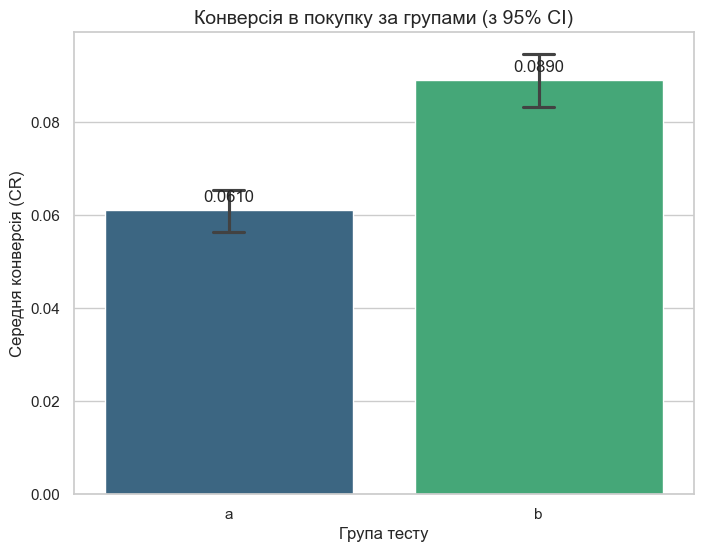

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Налаштування стилю
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Оновлений виклик функції: додаємо hue та legend=False
ax = sns.barplot(
    x='test_group', 
    y='conversion', 
    data=df, 
    hue='test_group',   # Явно вказуємо змінну для кольору
    palette='viridis', 
    capsize=.1, 
    errorbar=('ci', 95), # Новий синтаксис замість ci=95
    legend=False         # Прибираємо легенду, бо вона дублює підписи на осі X
)

# Додаємо підписи
plt.title('Конверсія в покупку за групами (з 95% CI)', fontsize=14)
plt.xlabel('Група тесту', fontsize=12)
plt.ylabel('Середня конверсія (CR)', fontsize=12)

# Додаємо числові значення над стовпчиками
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.show()

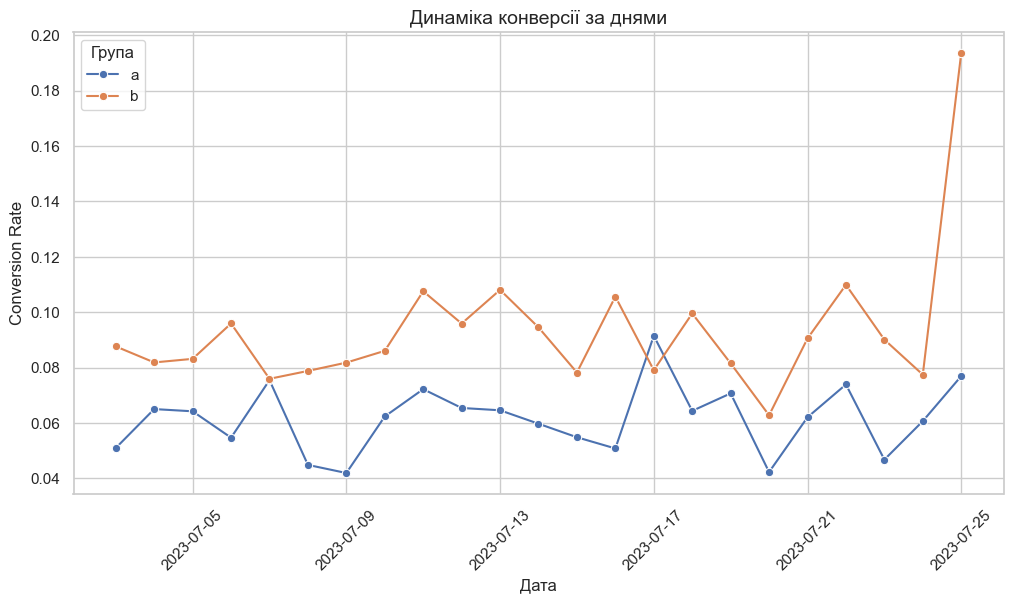

In [12]:
# Групуємо за датою та тестовою групою
df['date'] = df['timestamp'].dt.date
daily_conversion = df.groupby(['date', 'test_group'])['conversion'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_conversion, x='date', y='conversion', hue='test_group', marker='o')

plt.title('Динаміка конверсії за днями', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Conversion Rate', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Група')
plt.show()

scipy.stats.ttest_ind: Ми застосували цей критерій, оскільки порівнюємо середні значення двох незалежних груп (А та В).t-статистика: Це значення показує розмір різниці між групами відносно стандартної помилки. Чим воно більше за модулем, тим менш ймовірно, що результат випадковий.p-value: Це головний показник значущості. Якщо він менший за 0,05, ми впевнені на 95%, що ефект від "знижки 50%" справжній, а не просто везіння.Нульова гіпотеза ($H_0$): Припускає, що новий дизайн екрана ніяк не впливає на загальну конверсію з інстала в платіж.

Оскільки ваша t_stat висока, а p-value низький, довірчі інтервали груп не перетинаються. Це дає вам подвійну впевненість у тому, що приріст конверсії з 6,10% до 8,90% — це стійкий результат, а не просто везіння під час 21-денного тесту.